In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate
from datetime import datetime

# Find all parquet files in the daily trades directory
directory = "/allah/data/trades/eth_usdt_daily_trades"
os.chdir(directory)  # Change to the target directory
files = glob.glob("*.parquet")
files.sort()

# Show available files
print(f"Found {len(files)} parquet files in {directory}:")
for i, file in enumerate(files, 1):
    file_size = os.path.getsize(file)
    human_size = f"{file_size / (1024 * 1024):.2f} MB"
    date_part = file.split('-trades-')[1].split('.')[0] if '-trades-' in file else ""
    print(f"{i}. {file} ({date_part}) - {human_size}")

# Ask which file to analyze
if files:
    try:
        file_idx = int(input("\nEnter file number to analyze (1-{0}): ".format(len(files)))) - 1
        if 0 <= file_idx < len(files):
            selected_file = files[file_idx]
            full_path = os.path.join(directory, selected_file)
            print(f"\nLoading: {selected_file}")
            
            # Load the file
            df = pd.read_parquet(selected_file)
            
            # Convert timestamp to datetime if exists
            if 'time' in df.columns and 'datetime' not in df.columns:
                df['datetime'] = pd.to_datetime(df['time'], unit='ms')
            
            # Print basic info
            print(f"\n=== DataFrame Info ===")
            print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
            print("\nColumn types:")
            for col, dtype in df.dtypes.items():
                print(f"  {col}: {dtype}")
            
            # Time range
            if 'datetime' in df.columns:
                min_time = df['datetime'].min()
                max_time = df['datetime'].max()
                time_span = max_time - min_time
                print(f"\nTime range: {min_time} to {max_time} (span: {time_span})")
            
            # Show sample
            print("\n=== Sample Data ===")
            display(df.head(10))
            
            # Summary statistics
            print("\n=== Summary Statistics ===")
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            if numeric_cols:
                stats_df = df[numeric_cols].describe().transpose()
                display(stats_df)
            
            # Plots
            if 'datetime' in df.columns and 'price' in df.columns:
                plt.figure(figsize=(12, 6))
                df.set_index('datetime')['price'].plot()
                plt.title('Price Over Time')
                plt.ylabel('Price')
                plt.grid(True, alpha=0.3)
                plt.show()
                
                # Distribution
                plt.figure(figsize=(10, 5))
                df['price'].plot.hist(bins=50, alpha=0.7)
                plt.title('Price Distribution')
                plt.xlabel('Price')
                plt.grid(True, alpha=0.3)
                plt.show()
        else:
            print("Invalid selection.")
    except ValueError:
        print("Please enter a valid number.")
else:
    print("No parquet files found in the daily trades directory!")

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Find only ETH_USDT feather files in the futures directory
directory = "/allah/freqtrade/user_data/data/binance/futures"
os.chdir(directory)  # Change to the target directory
files = glob.glob("ETH_USDT*.feather")
files.sort()

# Show available ETH_USDT files
print(f"Found {len(files)} ETH_USDT feather files in {directory}:")
for i, file in enumerate(files, 1):
    file_size = os.path.getsize(file)
    human_size = f"{file_size / (1024 * 1024):.2f} MB"
    # Extract data type information
    data_type = file.replace('ETH_USDT-', '').replace('.feather', '')
    print(f"{i}. {file} - ({data_type}) - {human_size}")

# Ask which file to analyze
if files:
    try:
        file_idx = int(input("\nEnter file number to analyze (1-{0}): ".format(len(files)))) - 1
        if 0 <= file_idx < len(files):
            selected_file = files[file_idx]
            print(f"\nLoading: {selected_file}")
            
            # Load the feather file
            df = pd.read_feather(selected_file)
            
            # Check if datetime column exists or needs conversion
            if 'date' in df.columns and pd.api.types.is_numeric_dtype(df['date']):
                df['datetime'] = pd.to_datetime(df['date'], unit='ms')
            elif 'date' in df.columns:
                df['datetime'] = pd.to_datetime(df['date'])
            
            # Set datetime as index if it exists
            if 'datetime' in df.columns:
                df = df.set_index('datetime')
            
            # Print basic info
            print(f"\n=== DataFrame Info ===")
            print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
            print("\nColumn types:")
            for col, dtype in df.dtypes.items():
                print(f"  {col}: {dtype}")
            
            # Time range
            if df.index.dtype.name == 'datetime64[ns]':
                min_time = df.index.min()
                max_time = df.index.max()
                time_span = max_time - min_time
                print(f"\nTime range: {min_time} to {max_time} (span: {time_span})")
            
            # Show sample
            print("\n=== Sample Data ===")
            display(df.head(10))
            
            # Summary statistics
            print("\n=== Summary Statistics ===")
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            if numeric_cols:
                stats_df = df[numeric_cols].describe().transpose()
                display(stats_df)
            
            # Plot based on file type
            plt.figure(figsize=(14, 7))
            
            # Identify what to plot based on filename
            if "funding_rate" in selected_file:
                # For funding rate files
                if 'rate' in df.columns:
                    df['rate'].plot()
                    plt.title('ETH/USDT Funding Rate')
                    plt.ylabel('Funding Rate')
                elif 'open' in df.columns:
                    df['open'].plot()
                    plt.title('ETH/USDT Funding Rate (Open)')
                    plt.ylabel('Rate')
            else:
                # For mark price or other files
                if 'open' in df.columns and 'high' in df.columns and 'low' in df.columns and 'close' in df.columns:
                    # Plot OHLC as candlestick if mplfinance is available
                    try:
                        import mplfinance as mpf
                        # Reset index to get datetime as column for mplfinance
                        plot_df = df.reset_index()
                        plot_df = plot_df.rename(columns={'datetime': 'Date'})
                        plot_df = plot_df.set_index('Date')
                        mpf.plot(plot_df, type='candle', style='yahoo', title='ETH/USDT Price')
                    except ImportError:
                        # Fallback to regular plot if mplfinance not available
                        df['close'].plot()
                        plt.title('ETH/USDT Close Price')
                        plt.ylabel('Price')
                elif 'close' in df.columns:
                    df['close'].plot()
                    plt.title('ETH/USDT Close Price')
                    plt.ylabel('Price')
                else:
                    # Plot the first numeric column
                    if numeric_cols:
                        df[numeric_cols[0]].plot()
                        plt.title(f'ETH/USDT {numeric_cols[0]}')
                        plt.ylabel(numeric_cols[0])
            
            plt.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            
            # Additional analysis for funding rate files
            if "funding_rate" in selected_file and 'rate' in df.columns:
                plt.figure(figsize=(12, 5))
                df['rate'].hist(bins=50)
                plt.title('ETH/USDT Funding Rate Distribution')
                plt.xlabel('Funding Rate')
                plt.grid(True, alpha=0.3)
                plt.show()
                
                print("\n=== ETH/USDT Funding Rate Analysis ===")
                print(f"Average funding rate: {df['rate'].mean():.8f}")
                print(f"Positive rate periods: {(df['rate'] > 0).sum()} ({(df['rate'] > 0).mean()*100:.2f}%)")
                print(f"Negative rate periods: {(df['rate'] < 0).sum()} ({(df['rate'] < 0).mean()*100:.2f}%)")
                print(f"Zero rate periods: {(df['rate'] == 0).sum()} ({(df['rate'] == 0).mean()*100:.2f}%)")
        else:
            print("Invalid selection.")
    except ValueError:
        print("Please enter a valid number.")
    except Exception as e:
        print(f"Error analyzing file: {str(e)}")
else:
    print("No ETH_USDT feather files found in the directory!")

In [1]:
import os
import pandas as pd
import numpy as np
from datetime import datetime, timezone
import glob
from tqdm import tqdm

# Directory with daily trade data
source_dir = "/allah/data/trades/eth_usdt_daily_trades"
# Output directory and file
output_dir = "/allah/freqtrade/user_data/data/binance/futures"
output_file = os.path.join(output_dir, "ETH_USDT_USDT-5s-futures.feather")

# Process files in batches to avoid memory issues
def process_files_in_batches(file_paths, timeframe='5s', batch_size=3):
    all_ohlcv_dfs = []
    
    # Process files in batches
    for i in range(0, len(file_paths), batch_size):
        batch_files = file_paths[i:i+batch_size]
        print(f"Processing batch {i//batch_size + 1}/{(len(file_paths) + batch_size - 1)//batch_size}")
        
        # Process each file in the batch
        batch_dfs = []
        for file_path in tqdm(batch_files, desc=f"Batch {i//batch_size + 1}"):
            # Load a single parquet file
            df = pd.read_parquet(file_path)
            
            # Ensure datetime column exists
            if 'datetime' not in df.columns and 'time' in df.columns:
                df['datetime'] = pd.to_datetime(df['time'], unit='ms')
            
            # Set datetime as index for resampling
            df = df.set_index('datetime')
            
            # Create OHLCV for this file
            ohlcv = df['price'].resample(timeframe).ohlc()
            volume = df['qty'].resample(timeframe).sum()
            
            # Combine OHLC and volume
            ohlcv['volume'] = volume
            
            # Reset index
            ohlcv = ohlcv.reset_index()
            
            # Add to batch results
            batch_dfs.append(ohlcv)
            
            # Clear memory
            del df
            
        # Combine batch results
        if batch_dfs:
            batch_combined = pd.concat(batch_dfs, ignore_index=False)
            all_ohlcv_dfs.append(batch_combined)
            
            # Clear memory
            del batch_dfs
            
    # Combine all batches
    print("Combining all batches...")
    final_df = pd.concat(all_ohlcv_dfs)
    
    # Remove any duplicate timestamps that might occur at file boundaries
    final_df = final_df.groupby('datetime').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }).reset_index()
    
    # Sort by timestamp
    final_df = final_df.sort_values('datetime')
    
    # Rename columns to match format of futures data
    final_df = final_df.rename(columns={
        'datetime': 'date',
        'open': 'open', 
        'high': 'high', 
        'low': 'low', 
        'close': 'close',
        'volume': 'volume'
    })
    
    # Convert timezone to UTC to match futures data format
    final_df['date'] = final_df['date'].dt.tz_localize(timezone.utc)
    
    return final_df

# Main process
def main():
    # Find all parquet files
    file_pattern = os.path.join(source_dir, "ETHUSDT-trades-*.parquet")
    files = sorted(glob.glob(file_pattern))
    
    if not files:
        print("No parquet files found!")
        return
    
    print(f"Found {len(files)} parquet files to process")
    
    # Process files in batches
    ohlcv_df = process_files_in_batches(files, timeframe='5s', batch_size=2)
    print(f"Created {len(ohlcv_df):,} OHLCV candles")
    
    # Save as feather file
    print(f"Saving to {output_file}...")
    ohlcv_df.to_feather(output_file)
    print("Done!")
    
    # Show sample of the created data
    print("\n=== Sample of created data ===")
    print(ohlcv_df.head(10))
    
    # Show file size
    file_size_mb = os.path.getsize(output_file) / (1024 * 1024)
    print(f"\nFile size: {file_size_mb:.2f} MB")
    
    # Verify the data types match the futures data
    print("\n=== Data Types ===")
    for col, dtype in ohlcv_df.dtypes.items():
        print(f"  {col}: {dtype}")

if __name__ == "__main__":
    main()

Found 17 parquet files to process
Processing batch 1/9


Batch 1: 100%|██████████| 2/2 [00:06<00:00,  3.32s/it]


Processing batch 2/9


Batch 2: 100%|██████████| 2/2 [00:06<00:00,  3.32s/it]


Processing batch 3/9


...

Processing batch 8/9


Batch 8: 100%|██████████| 2/2 [00:01<00:00,  1.71it/s]


Processing batch 9/9


Batch 9: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s]

Combining all batches...
Created 293,760 OHLCV candles
Saving to /allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-5s-futures.feather...
Done!

=== Sample of created data ===
                       date     open     high      low    close   volume
0 2025-03-01 00:00:00+00:00  2236.59  2236.74  2236.59  2236.59   62.288
1 2025-03-01 00:00:05+00:00  2236.59  2237.47  2236.59  2236.62  409.673
2 2025-03-01 00:00:10+00:00  2236.63  2237.72  2236.47  2237.26  183.504
3 2025-03-01 00:00:15+00:00  2237.25  2237.85  2237.25  2237.85  171.908
4 2025-03-01 00:00:20+00:00  2237.86  2237.94  2237.79  2237.80  207.517
5 2025-03-01 00:00:25+00:00  2237.80  2237.80  2236.20  2236.55  325.011
6 2025-03-01 00:00:30+00:00  2236.55  2236.62  2236.35  2236.36  131.742
7 2025-03-01 00:00:35+00:00  2236.35  2236.36  2236.00  2236.01   54.287
8 2025-03-01 00:00:40+00:00  2236.01  2236.16  2236.00  2236.00   60.281
9 2025-03-01 00:00:45+00:00  2236.01  2236.01  2235.35  2235.35   73.142

File size

Reading file: ETH_USDT_USDT-5s-futures.feather (7.78 MB)

=== DataFrame Info ===
Shape: 293760 rows × 6 columns
Memory usage: 13.45 MB

Column types:
  date: datetime64[ns, UTC]
  open: float64
  high: float64
  low: float64
  close: float64
  volume: float64

Time range: 2025-03-01 00:00:00+00:00 to 2025-03-17 23:59:55+00:00
Time span: 16 days 23:59:55
Number of days: 17.00 days
Average interval between candles: 5.00 seconds
Candle coverage: 100.00% of expected 5s candles

=== Sample Data ===


,date,open,high,low,close,volume
0,2025-03-01 00:00:00+00:00,2236.59,2236.74,2236.59,2236.59,62.288
1,2025-03-01 00:00:05+00:00,2236.59,2237.47,2236.59,2236.62,409.673
2,2025-03-01 00:00:10+00:00,2236.63,2237.72,2236.47,2237.26,183.504
3,2025-03-01 00:00:15+00:00,2237.25,2237.85,2237.25,2237.85,171.908
4,2025-03-01 00:00:20+00:00,2237.86,2237.94,2237.79,2237.80,207.517
5,2025-03-01 00:00:25+00:00,2237.80,2237.80,2236.20,2236.55,325.011
6,2025-03-01 00:00:30+00:00,2236.55,2236.62,2236.35,2236.36,131.742
7,2025-03-01 00:00:35+00:00,2236.35,2236.36,2236.00,2236.01,54.287
8,2025-03-01 00:00:40+00:00,2236.01,2236.16,2236.00,2236.00,60.281
9,2025-03-01 00:00:45+00:00,2236.01,2236.01,2235.35,2235.35,73.142



=== Summary Statistics ===


,open,high,low,close,volume
count,293760.000000,293760.000000,293760.000000,293760.000000,293760.000000
mean,2070.701776,2071.095493,2070.306411,2070.700820,321.121629
std,165.866472,165.936934,165.797652,165.866347,827.332833
min,1757.990000,1761.610000,1752.500000,1757.990000,0.016000
25%,1909.370000,1909.670000,1909.100000,1909.370000,51.732000
50%,2087.770000,2088.240000,2087.225000,2087.760000,121.381000
75%,2200.220000,2200.630000,2199.970000,2200.230000,289.817000
max,2548.370000,2550.000000,2544.770000,2548.390000,49664.507000


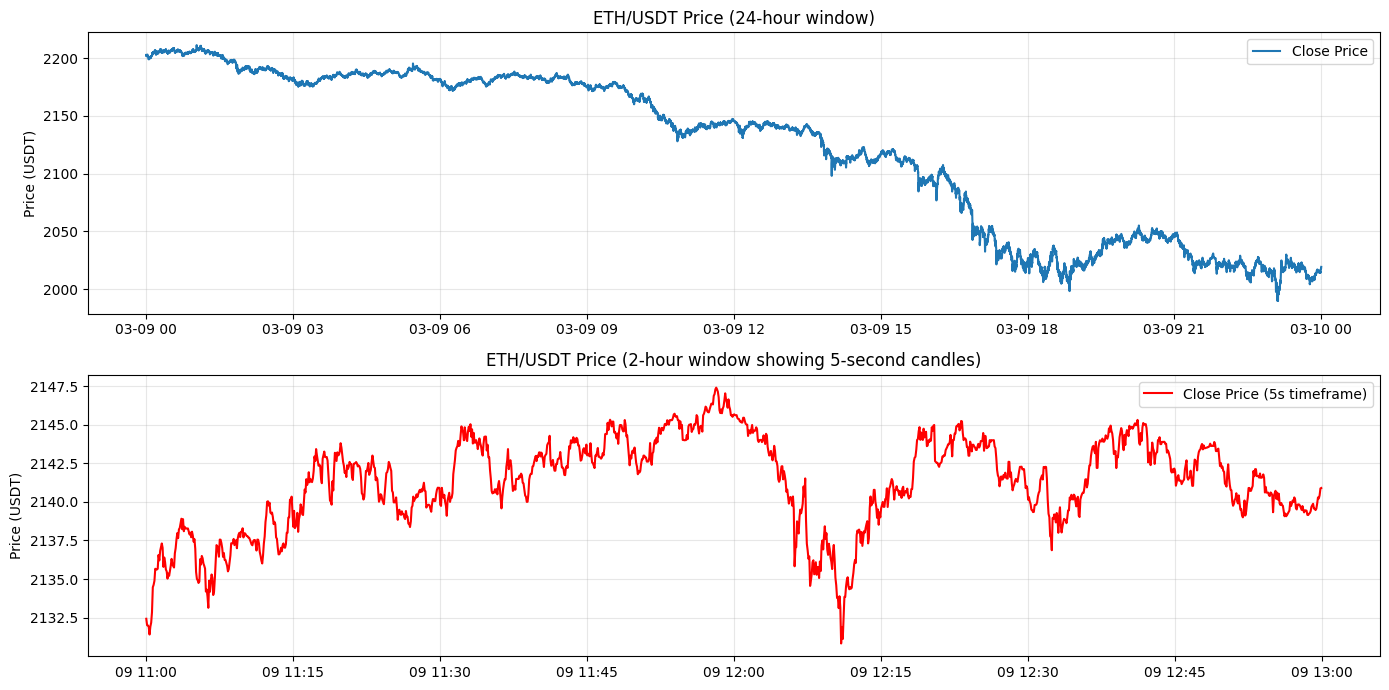

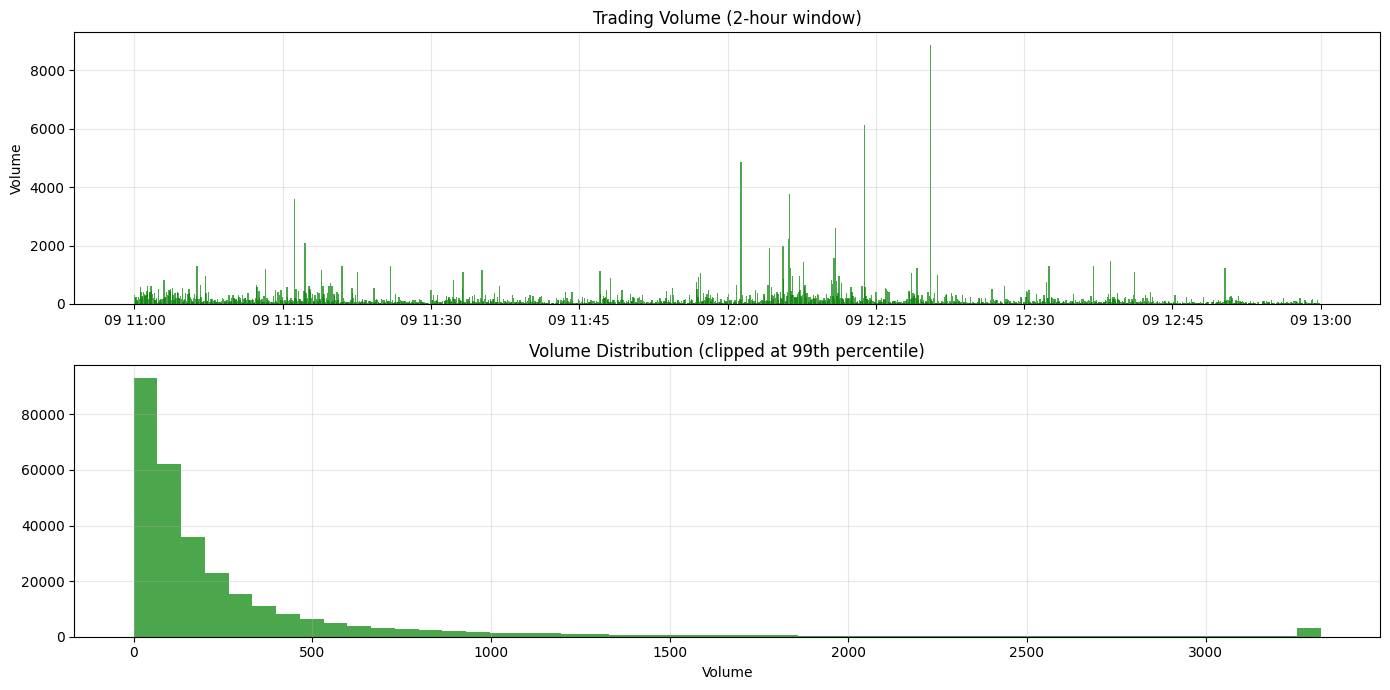

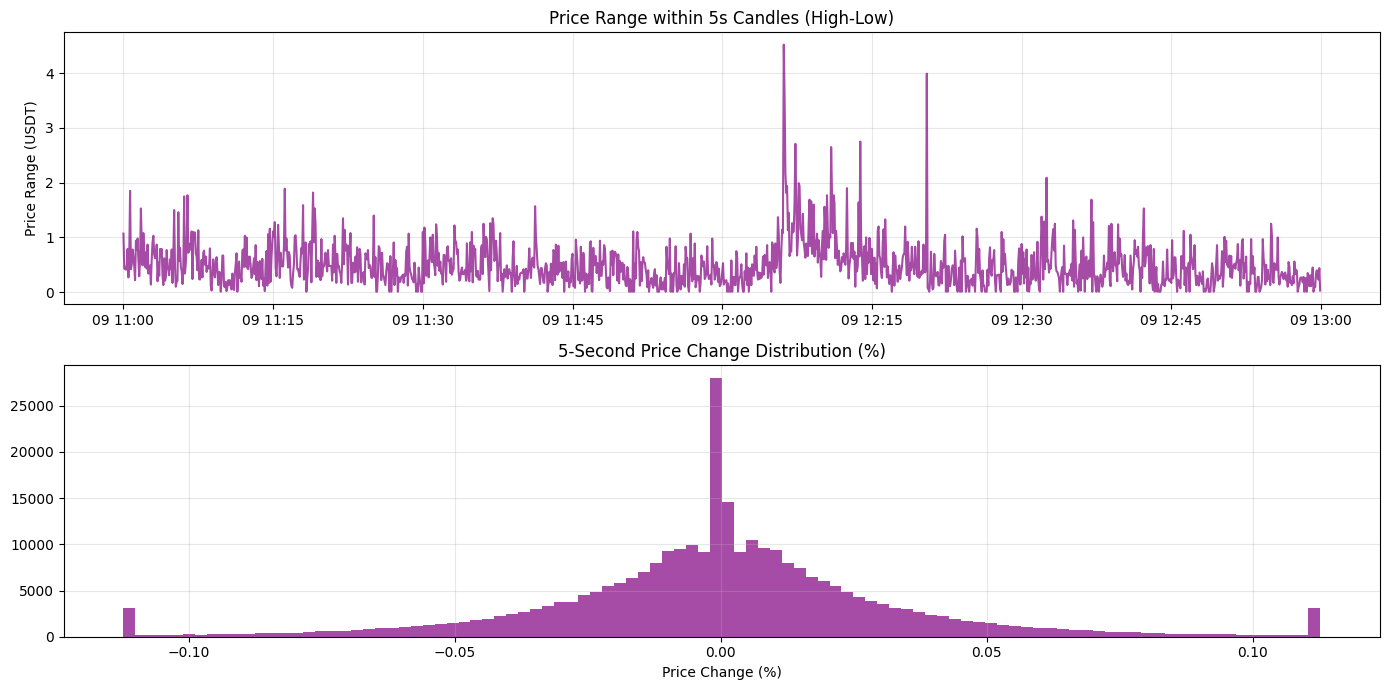

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta

# File to read
file_path = "/allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-5s-futures.feather"

# Check if file exists
if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}")
else:
    # Get file size
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
    print(f"Reading file: ETH_USDT_USDT-5s-futures.feather ({file_size_mb:.2f} MB)")

    # Load the feather file
    df = pd.read_feather(file_path)
    
    # Basic info
    print(f"\n=== DataFrame Info ===")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / (1024 * 1024):.2f} MB")
    
    # Column information
    print("\nColumn types:")
    for col, dtype in df.dtypes.items():
        print(f"  {col}: {dtype}")
    
    # Time range
    if 'date' in df.columns:
        min_time = df['date'].min()
        max_time = df['date'].max()
        time_span = max_time - min_time
        print(f"\nTime range: {min_time} to {max_time}")
        print(f"Time span: {time_span}")
        print(f"Number of days: {time_span.total_seconds() / (24*60*60):.2f} days")
        
        # Calculate time interval between candles
        if len(df) > 1:
            df = df.sort_values('date')
            time_diffs = df['date'].diff()[1:].dt.total_seconds()
            avg_interval = time_diffs.mean()
            print(f"Average interval between candles: {avg_interval:.2f} seconds")
            print(f"Candle coverage: {len(df) / (time_span.total_seconds() / 5) * 100:.2f}% of expected 5s candles")
    
    # Show sample
    print("\n=== Sample Data ===")
    display(df.head(10))
    
    # Basic statistics
    print("\n=== Summary Statistics ===")
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    stats_df = df[numeric_cols].describe()
    display(stats_df)
    
    # Create 5-second price chart (showing a small time window)
    plt.figure(figsize=(14, 7))
    
    # Set plot datetime index
    if 'date' in df.columns:
        # Only plot a small window to see the 5-second details
        # Choose a random active period (24 hours from the middle of the dataset)
        mid_point = min_time + (max_time - min_time) / 2
        start_time = mid_point - timedelta(hours=12)
        end_time = mid_point + timedelta(hours=12)
        
        # Filter data for this time window
        plot_df = df[(df['date'] >= start_time) & (df['date'] <= end_time)]
        
        # Further limit to 2 hours for better visibility of 5-second candles
        mid_window = start_time + timedelta(hours=12)
        narrow_start = mid_window - timedelta(hours=1)
        narrow_end = mid_window + timedelta(hours=1)
        narrow_df = df[(df['date'] >= narrow_start) & (df['date'] <= narrow_end)]
        
        # Plot full 24-hour window
        plt.subplot(2, 1, 1)
        plt.plot(plot_df['date'], plot_df['close'], label='Close Price')
        plt.title('ETH/USDT Price (24-hour window)')
        plt.ylabel('Price (USDT)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Plot narrow 2-hour window to see 5-second details
        plt.subplot(2, 1, 2)
        plt.plot(narrow_df['date'], narrow_df['close'], label='Close Price (5s timeframe)', color='red')
        plt.title('ETH/USDT Price (2-hour window showing 5-second candles)')
        plt.ylabel('Price (USDT)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        # Show volume analysis
        plt.figure(figsize=(14, 7))
        
        # Volume over time (same 2-hour window)
        plt.subplot(2, 1, 1)
        plt.bar(narrow_df['date'], narrow_df['volume'], width=0.0001, alpha=0.7, color='green')
        plt.title('Trading Volume (2-hour window)')
        plt.ylabel('Volume')
        plt.grid(True, alpha=0.3)
        
        # Volume distribution
        plt.subplot(2, 1, 2)
        plt.hist(df['volume'].clip(upper=df['volume'].quantile(0.99)), bins=50, alpha=0.7, color='green')
        plt.title('Volume Distribution (clipped at 99th percentile)')
        plt.xlabel('Volume')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Calculate high-low range directly in the plot (instead of adding to dataframe)
        plt.figure(figsize=(14, 7))
        
        # High-Low range over time
        plt.subplot(2, 1, 1)
        plt.plot(narrow_df['date'], narrow_df['high'] - narrow_df['low'], color='purple', alpha=0.7)
        plt.title('Price Range within 5s Candles (High-Low)')
        plt.ylabel('Price Range (USDT)')
        plt.grid(True, alpha=0.3)
        
        # Price change distribution (calculate on the fly)
        price_change = df['close'].pct_change() * 100  # percentage change
        plt.subplot(2, 1, 2)
        plt.hist(price_change.dropna().clip(lower=price_change.quantile(0.01), 
                                            upper=price_change.quantile(0.99)), 
                bins=100, alpha=0.7, color='purple')
        plt.title('5-Second Price Change Distribution (%)')
        plt.xlabel('Price Change (%)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

Drawing price chart for entire dataset
Time range: 2025-03-01 00:00:00+00:00 to 2025-03-17 23:59:55+00:00
Time span: 16 days 23:59:55 (17.00 days)
Number of data points: 293,760


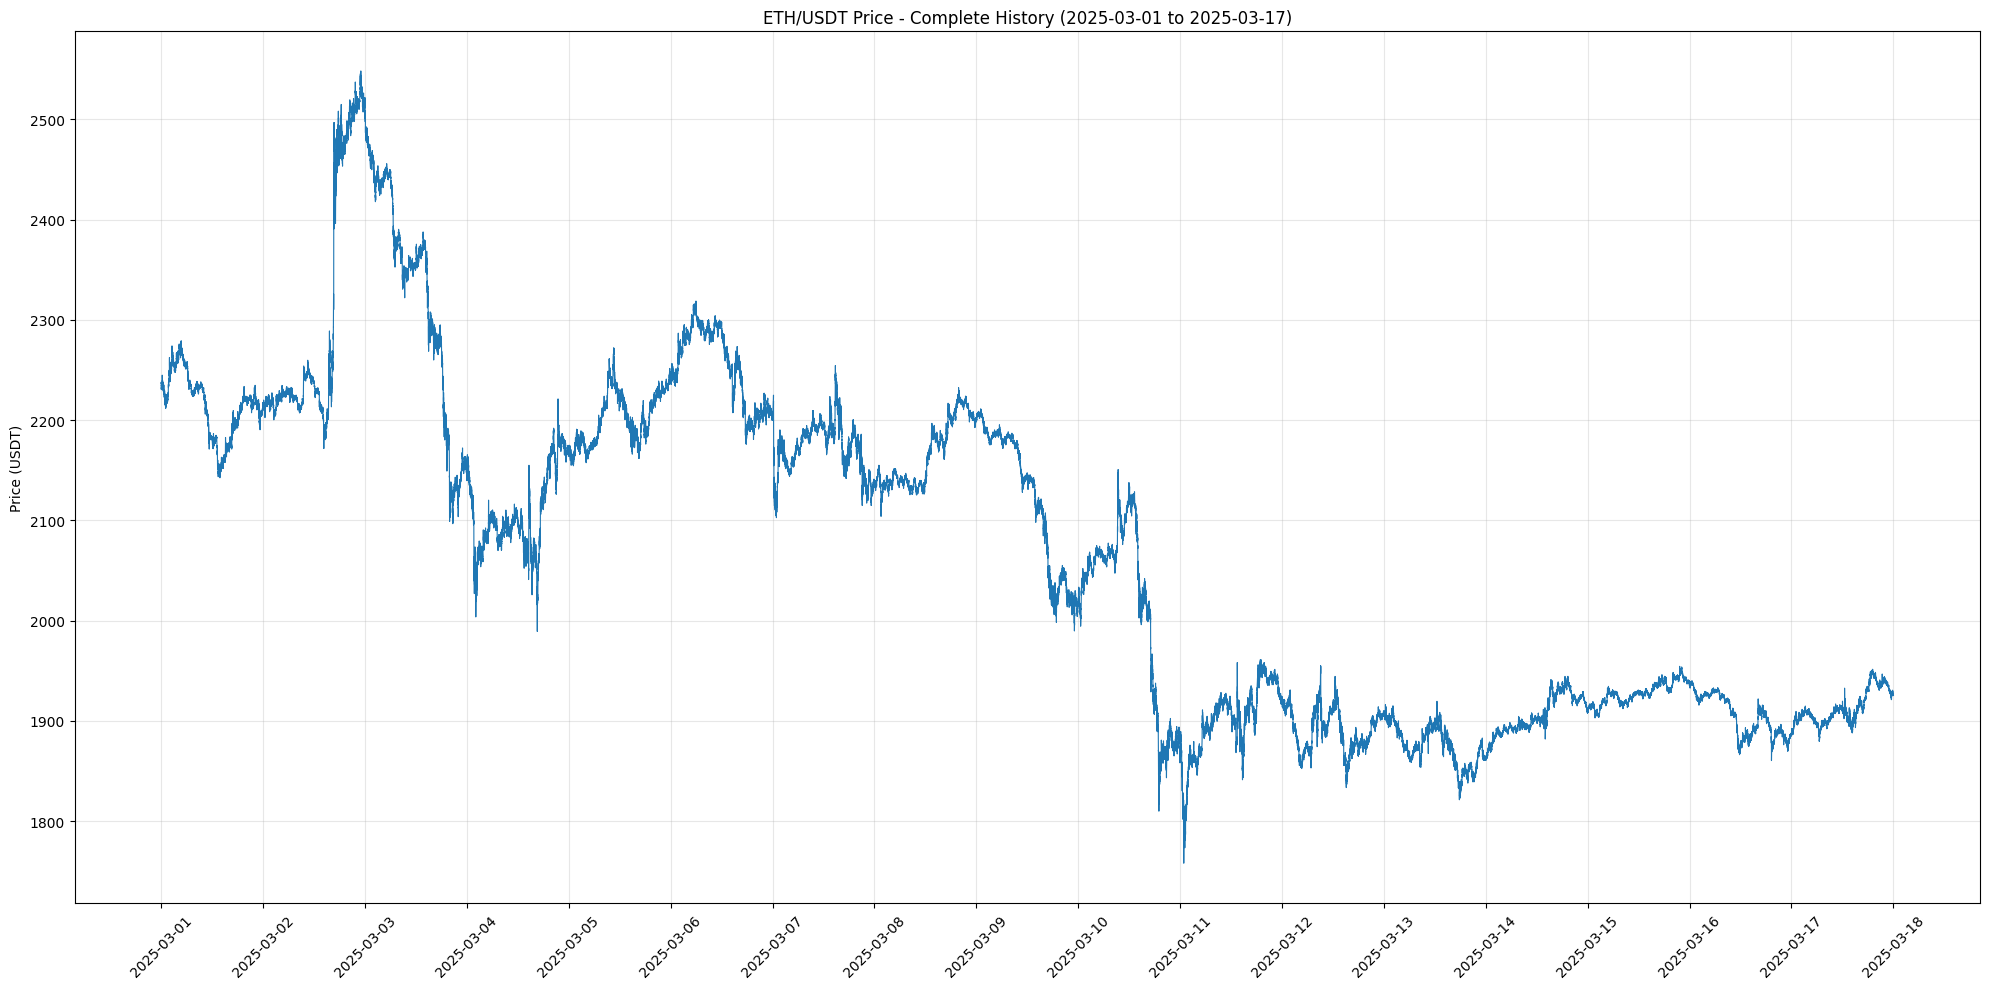

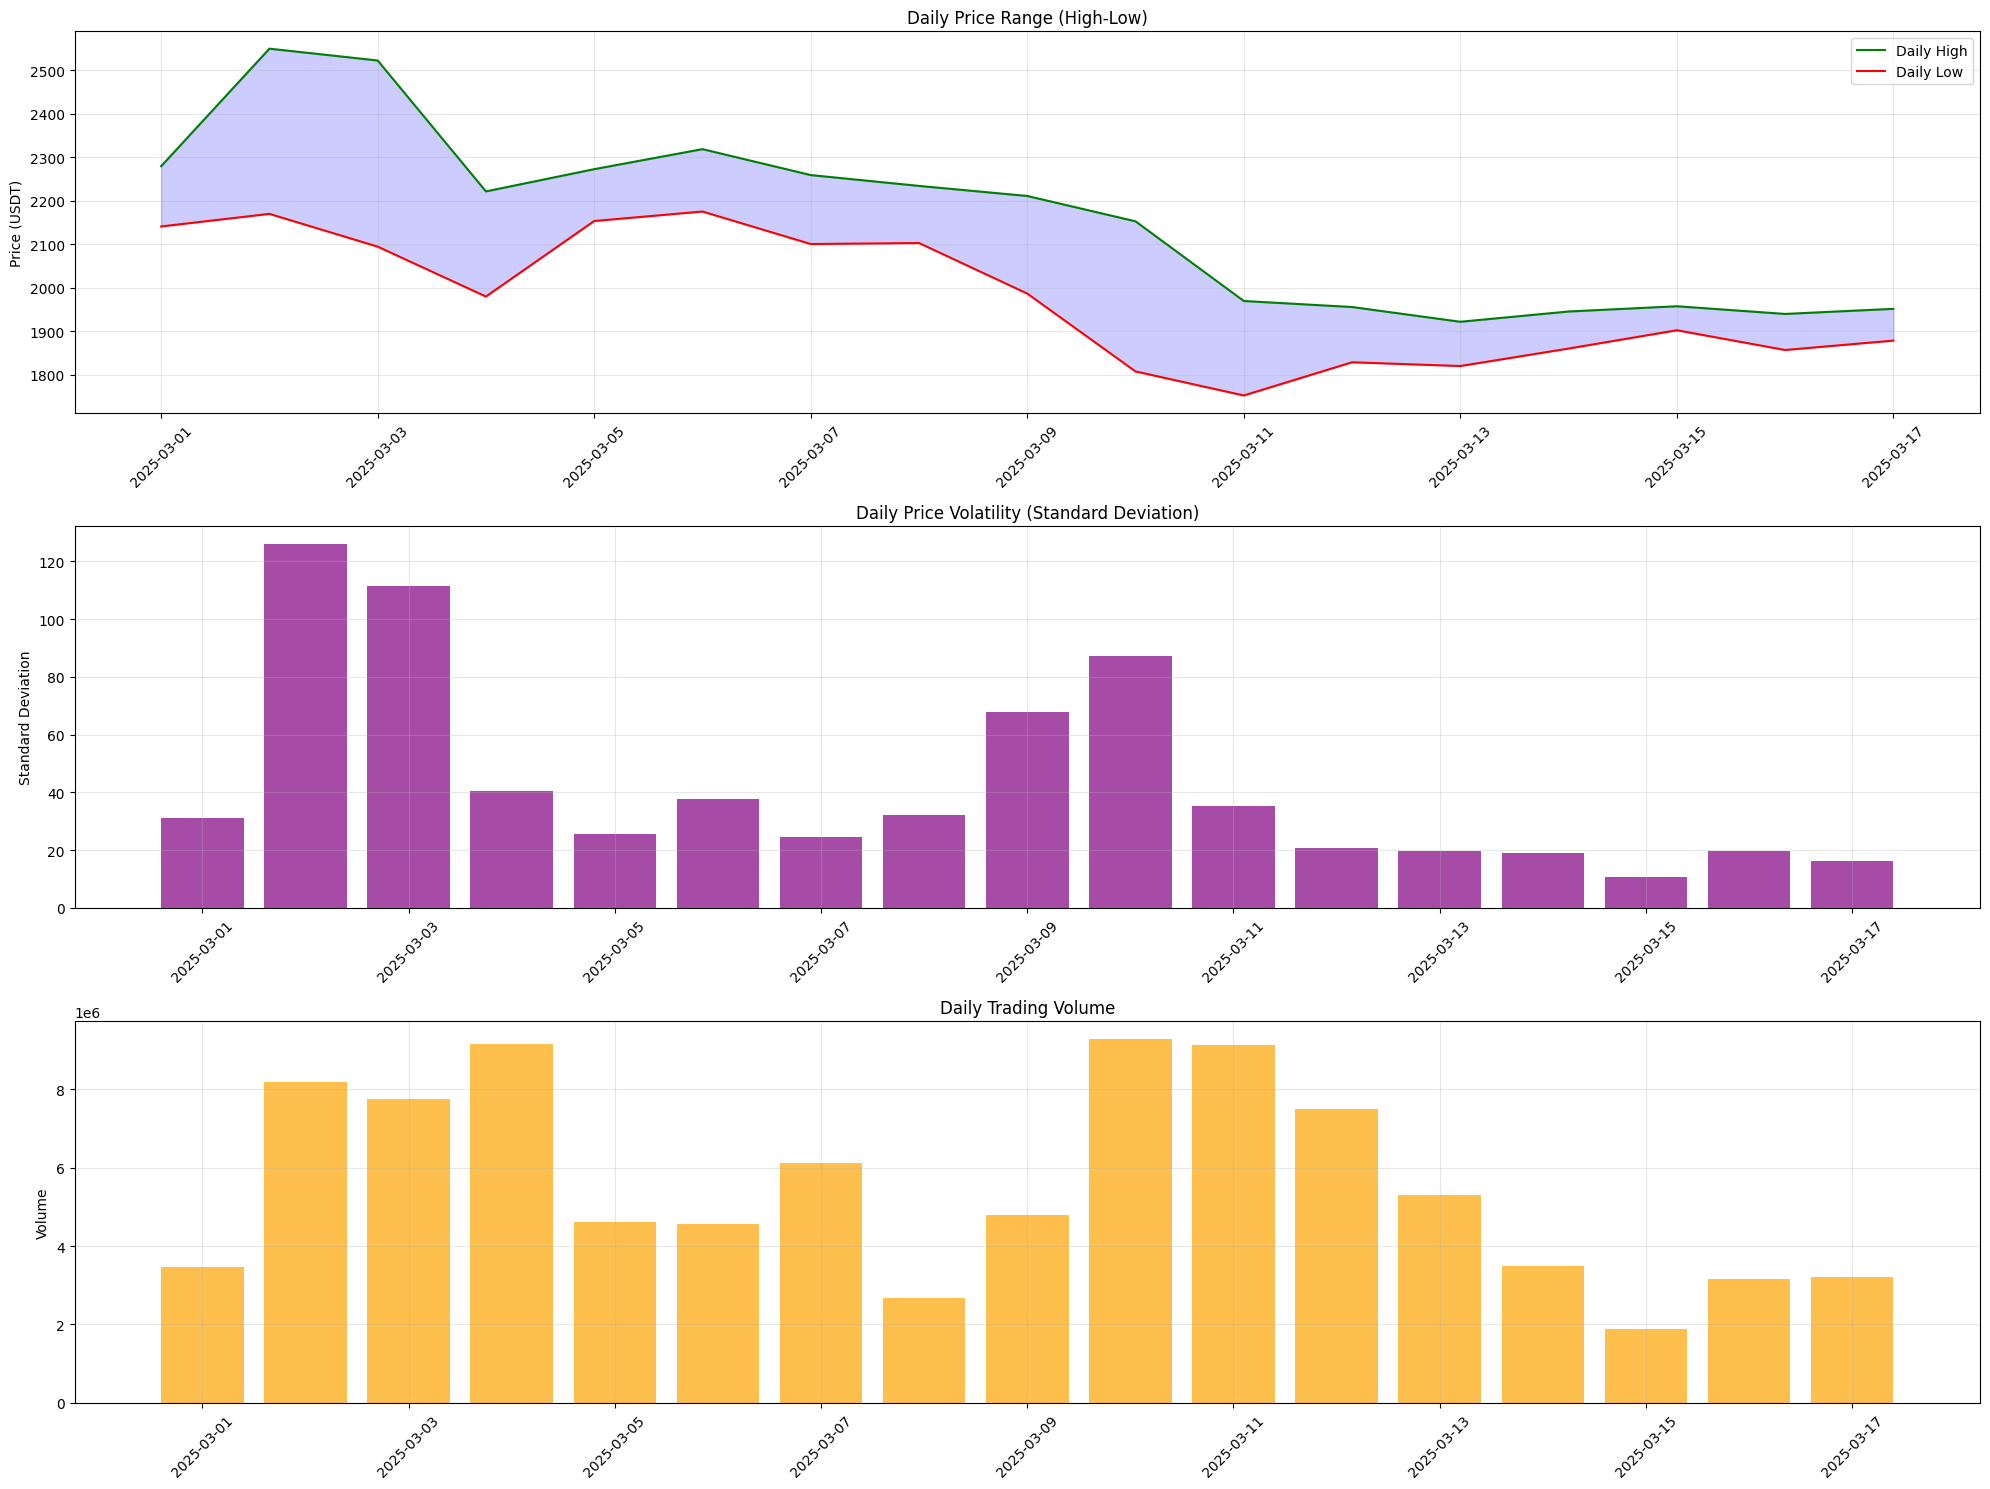


Creating hourly candlestick chart...


/tmp/ipykernel_24864/282826262.py:106: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df.resample('1H', on='date').agg({


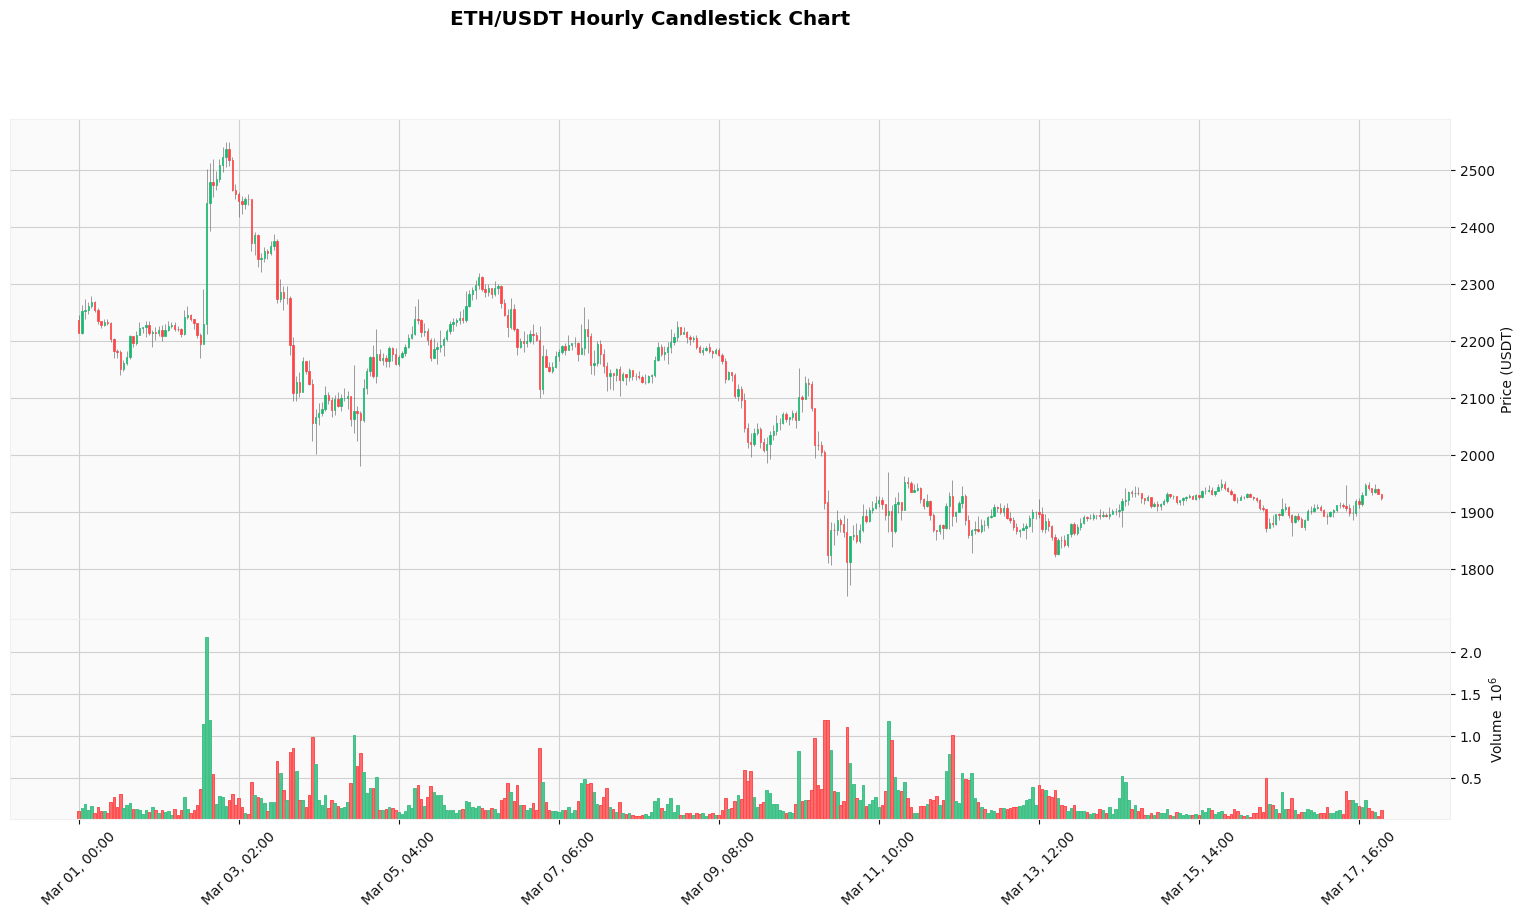

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime, timedelta
import matplotlib.dates as mdates

# File to read
file_path = "/allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-5s-futures.feather"

# Check if file exists
if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}")
else:
    # Load the feather file
    df = pd.read_feather(file_path)
    
    # Sort by date to ensure chronological order
    df = df.sort_values('date')
    
    # Get time range information
    min_time = df['date'].min()
    max_time = df['date'].max()
    time_span = max_time - min_time
    days = time_span.total_seconds() / (24*60*60)
    
    print(f"Drawing price chart for entire dataset")
    print(f"Time range: {min_time} to {max_time}")
    print(f"Time span: {time_span} ({days:.2f} days)")
    print(f"Number of data points: {len(df):,}")
    
    # Create a larger figure for detailed viewing
    plt.figure(figsize=(20, 10))
    
    # Plot the full price history
    plt.plot(df['date'], df['close'], linewidth=0.8)
    plt.title(f'ETH/USDT Price - Complete History ({min_time.date()} to {max_time.date()})')
    plt.ylabel('Price (USDT)')
    plt.grid(True, alpha=0.3)
    
    # Format x-axis to show readable dates
    if days > 180:
        # For datasets longer than 6 months, show monthly ticks
        plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    elif days > 30:
        # For datasets longer than a month, show weekly ticks
        plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    else:
        # For shorter datasets, show daily ticks
        plt.gca().xaxis.set_major_locator(mdates.DayLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Plot key price statistics over time
    plt.figure(figsize=(20, 15))
    
    # Daily high and low prices (resample to daily)
    plt.subplot(3, 1, 1)
    daily_high = df.resample('D', on='date')['high'].max()
    daily_low = df.resample('D', on='date')['low'].min()
    
    plt.plot(daily_high.index, daily_high, color='green', label='Daily High')
    plt.plot(daily_low.index, daily_low, color='red', label='Daily Low')
    plt.fill_between(daily_high.index, daily_high, daily_low, alpha=0.2, color='blue')
    plt.title('Daily Price Range (High-Low)')
    plt.ylabel('Price (USDT)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Price volatility (daily standard deviation)
    plt.subplot(3, 1, 2)
    daily_volatility = df.resample('D', on='date')['close'].std()
    plt.bar(daily_volatility.index, daily_volatility, width=0.8, alpha=0.7, color='purple')
    plt.title('Daily Price Volatility (Standard Deviation)')
    plt.ylabel('Standard Deviation')
    plt.grid(True, alpha=0.3)
    
    # Daily trading volume
    plt.subplot(3, 1, 3)
    daily_volume = df.resample('D', on='date')['volume'].sum()
    plt.bar(daily_volume.index, daily_volume, width=0.8, alpha=0.7, color='orange')
    plt.title('Daily Trading Volume')
    plt.ylabel('Volume')
    plt.grid(True, alpha=0.3)
    
    # Format dates for all subplots
    for ax in plt.gcf().get_axes():
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        plt.sca(ax)
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Create a candlestick chart using a longer timeframe
    # (hourly candles for better visibility)
    print("\nCreating hourly candlestick chart...")
    
    # Resample to hourly candles
    hourly = df.resample('1H', on='date').agg({
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    })
    
    # Reset index to get date as a column
    hourly = hourly.reset_index()
    
    try:
        import mplfinance as mpf
        
        # Prepare data for mplfinance
        hourly_plot = hourly.copy()
        hourly_plot = hourly_plot.rename(columns={'date': 'Date'})
        hourly_plot = hourly_plot.set_index('Date')
        
        # Create candlestick chart
        mpf.plot(hourly_plot, type='candle', style='yahoo', 
                title='ETH/USDT Hourly Candlestick Chart',
                ylabel='Price (USDT)',
                volume=True,
                figsize=(20, 10))
                
    except ImportError:
        print("mplfinance package not available. Using regular plotting instead.")
        
        # Create a simple high-low-close chart instead
        plt.figure(figsize=(20, 10))
        
        # Plot high, low, close
        plt.plot(hourly['date'], hourly['high'], 'g-', alpha=0.3, label='High')
        plt.plot(hourly['date'], hourly['low'], 'r-', alpha=0.3, label='Low')
        plt.plot(hourly['date'], hourly['close'], 'b-', linewidth=1.0, label='Close')
        
        plt.title('ETH/USDT Hourly Price Chart')
        plt.ylabel('Price (USDT)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        
        # Format x-axis dates
        plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()